In [4]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

import numpy as np

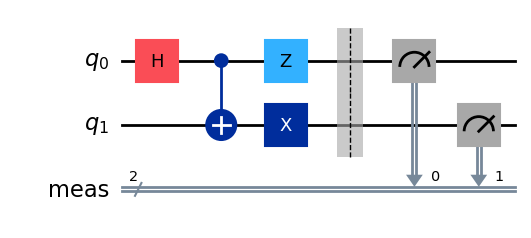

In [11]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.x(1)
qc.z(0)

qc.measure_active()

qc.draw("mpl")

In [5]:
service = QiskitRuntimeService()
backend = service.backend("ibm_marrakesh")

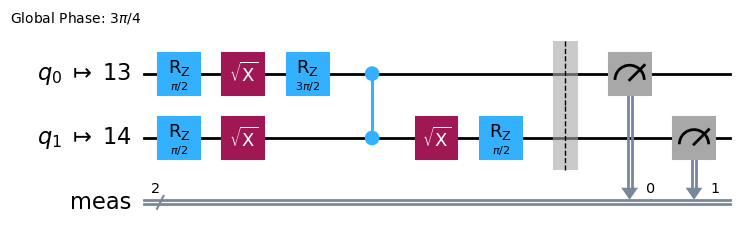

In [10]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

In [6]:
sampler = Sampler(mode=backend)

In [6]:
#job = sampler.run([qc_isa], shots=10000)
job = service.job("d8enm107jphs739l2bog")
res = job.result()
counts = res[0].data.meas.get_counts()

counts = {'10': 5021, '01': 4773, '00': 147, '11': 59}


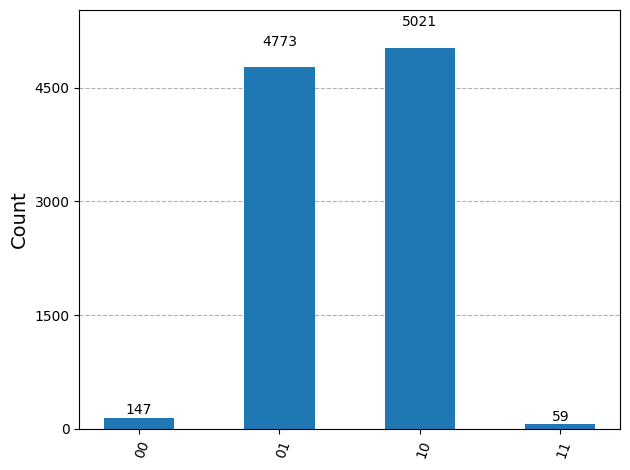

In [16]:
print("counts =", counts)

plot_histogram(data=counts)

AttributeError: 'DataBin' object has no attribute 'evs'